In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import json
from tqdm import tqdm
from inference_interface import template_to_multihist
import scipy.stats as stats
from appletree.utils import load_json
# from light_wimp_data_release import Template
# from light_wimp_data_release import make_spectrum, load_default_yield_model, produce_templates
from scipy.interpolate import interp1d
# Just some plotting settings
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import Normalize
import sys
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LogNorm

mpl.rcParams["figure.dpi"] = 200
mpl.rcParams["figure.figsize"] = [4, 3]
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 9
mpl.rcParams["mathtext.fontset"] = "dejavuserif"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Response Matrix

In [9]:
# sys.path.append('.')
from utils import basis_er, basis_nr, centers_to_edges, cs2_edges

In [17]:
path = "./data/orthonormal_basis"

for t, basis in zip(['nr'], [basis_nr]):

    for tqy in [-3, -2, -1, 0, 1, 2, 3]:
    
        for sr in ['sr0', 'sr1', 'sr2']:
            
            response = dict(energy_kev=basis)
        
            for i_e, e in tqdm(enumerate(basis)):
                
                file_name = os.path.join(
                    path,
                    f"template_XENONnT_{sr}_{t}_mono_{e}_tqy_{tqy}_1d.h5"
                )
                mh = template_to_multihist(file_name)
                mh["template"]
                for i, _rate in enumerate(mh['template'].histogram):
                    if f's2_bin_{i}' not in response:
                        response[f's2_bin_{i}'] = []
                    response[f's2_bin_{i}'].append(_rate)
            
            response = pd.DataFrame(response)  
            response.to_csv(f'./response/response_{t}_tqy_{tqy}_{sr}.csv', index=False)


50it [00:00, 56.74it/s]
50it [00:00, 55.92it/s]
50it [00:00, 60.24it/s]
50it [00:00, 58.76it/s]
50it [00:00, 72.40it/s]
50it [00:00, 73.03it/s]
50it [00:00, 81.02it/s]
50it [00:00, 120.03it/s]
50it [00:00, 110.50it/s]
50it [00:00, 88.39it/s]
50it [00:00, 142.39it/s]
50it [00:00, 150.10it/s]
50it [00:00, 78.78it/s]
50it [00:00, 60.90it/s]
50it [00:00, 72.61it/s]
50it [00:00, 76.24it/s]
50it [00:00, 67.03it/s]
50it [00:00, 89.89it/s]
50it [00:00, 114.01it/s]
50it [00:00, 115.52it/s]
50it [00:00, 141.66it/s]


# Plot

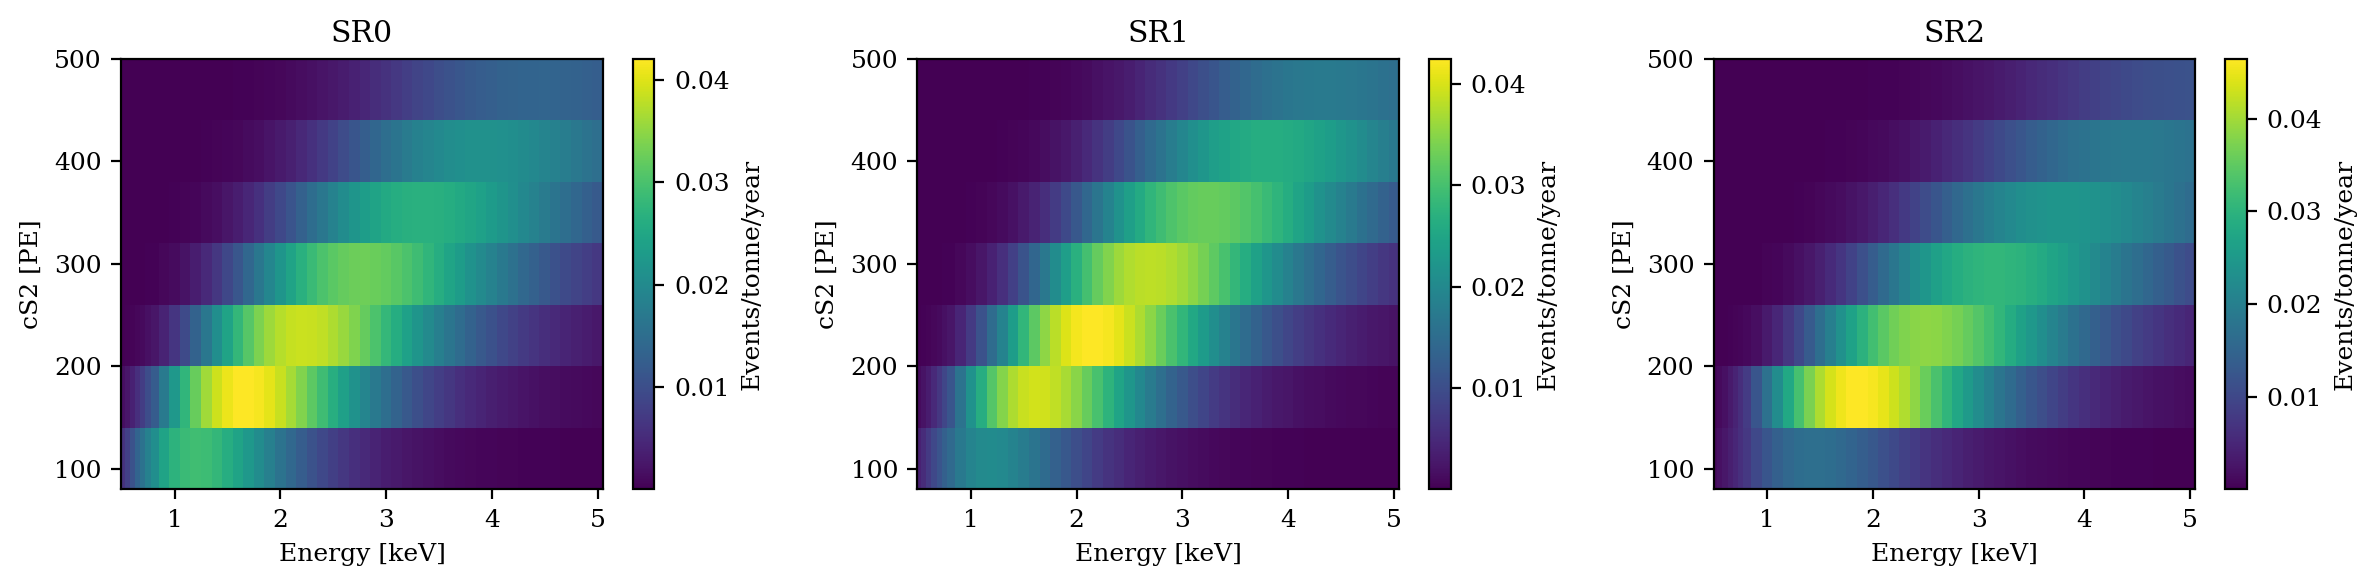

In [11]:
for t in ['nr']:

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    for i, sr in enumerate(['sr0', 'sr1', 'sr2']):
    
        response = pd.read_csv(f'./response/response_{t}_tqy_0_{sr}.csv')
        energy_kev = response['energy_kev'].values
        response_matrix = response.values[:, 1:]
        energy_kev.shape, response_matrix.shape
    
        ax = axes[i]
        im = ax.pcolormesh(
            centers_to_edges(energy_kev),
            cs2_edges,
            response_matrix.T,
            # origin="lower",
            # aspect="auto",
            # extent=[energy_kev.min(), energy_kev.max(), 0, response_matrix.shape[1]],
            # norm=LogNorm(vmin=response_matrix.min(), vmax=response_matrix.max()) if response_matrix.size else None,
    )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Events/tonne/year")
        
        ax.set_xlabel("Energy [keV]")
        ax.set_ylabel("cS2 [PE]")
        ax.set_title(sr.upper())
    
    plt.tight_layout()
    plt.savefig(f'./fig/response_{t}.png')
    plt.show()

# Background templates

In [12]:
from utils import cs2_centers

In [14]:
path = "./data/templates"
for sr in ['sr0', 'sr1', 'sr2']:
    
    background = dict(background=['cevns', 'de', 'ae', 'cathode'])

    for i_e, e in tqdm(enumerate(['cevns', 'de', 'ae', 'cathode'])):

        if e == 'cevns':
            _file_name = f"science_roi_background_{sr}_template_{e}_tqy_0_1d.h5"
        elif e == 'de' or e == 'ae':
            _file_name = f"science_roi_background_{sr}_template_{e}_1d.h5"
        elif e == 'cathode':
            _file_name = f"science_roi_background_{sr}_template_{e}_tsys_0_1d.h5"
        
        file_name = os.path.join(
            path,
            _file_name
        )
        mh = template_to_multihist(file_name)
        
        for i, _rate in enumerate(mh['template'].histogram):
            if f's2_bin_{i}' not in background:
                background[f's2_bin_{i}'] = []
            background[f's2_bin_{i}'].append(_rate)
    
    background = pd.DataFrame(background)  
    background.to_csv(f'./data/background_{sr}.csv', index=False)


4it [00:00, 591.25it/s]
4it [00:00, 641.53it/s]
4it [00:00, 169.61it/s]


In [15]:
background

,background,s2_bin_0,s2_bin_1,s2_bin_2,s2_bin_3,s2_bin_4,s2_bin_5,s2_bin_6
0,cevns,2.516337e+00,4.080432e+00,1.264568e+00,3.330969e-01,8.203999e-02,2.147595e-02,6.825902e-03
1,de,1.162054e+00,1.620898e+00,7.448161e-01,3.990714e-01,2.367472e-01,1.763884e-01,8.321313e-02
2,ae,2.572788e-11,2.572788e-11,2.572788e-11,2.572788e-11,2.572788e-11,2.572788e-11,2.572788e-11
3,cathode,7.746952e+01,1.116164e+02,5.121380e+01,3.064313e+01,1.852688e+01,1.385663e+01,6.984031e+00
